In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import scipy.integrate as scint
import scipy.optimize as scopt

In [2]:
# Importing growth data
tf_i = 72
OD_data = pd.read_csv("expt_growth_data.csv")
time = OD_data["time(min)"].to_numpy()[:tf_i]
OD_blank = 0.078
D1 = OD_data["D1"].to_numpy()[:tf_i] - OD_blank
D2 = OD_data["D2"].to_numpy()[:tf_i] - OD_blank
D3 = OD_data["D3"].to_numpy()[:tf_i] - OD_blank
D4 = OD_data["D4"].to_numpy()[:tf_i] - OD_blank
B1 = OD_data["B1"].to_numpy()[:tf_i] - OD_blank
B2 = OD_data["B2"].to_numpy()[:tf_i] - OD_blank
B3 = OD_data["B3"].to_numpy()[:tf_i] - OD_blank

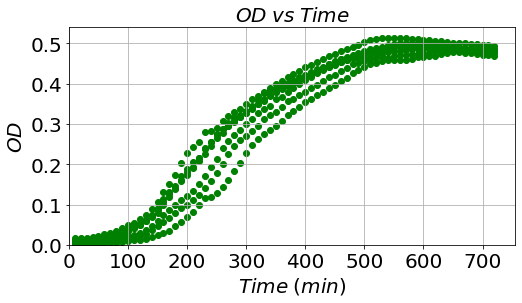

In [3]:
# Plot raw OD data
fig, ax = plt.subplots(1, 1, figsize=(8, 4), sharex='col')
for dataset in [D1, D2, D3, D4, B1, B2, B3]:
    ax.scatter(time, dataset, label='Experiment', color='green')
ax.set_xlabel('$Time \; (min)$', fontsize=20)
ax.set_ylabel(r'$OD$', fontsize=20)
ax.set_title(r'$OD \; vs \; Time$', fontsize=20)
ax.set_xlim(0)
ax.set_ylim(0)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.grid(True)

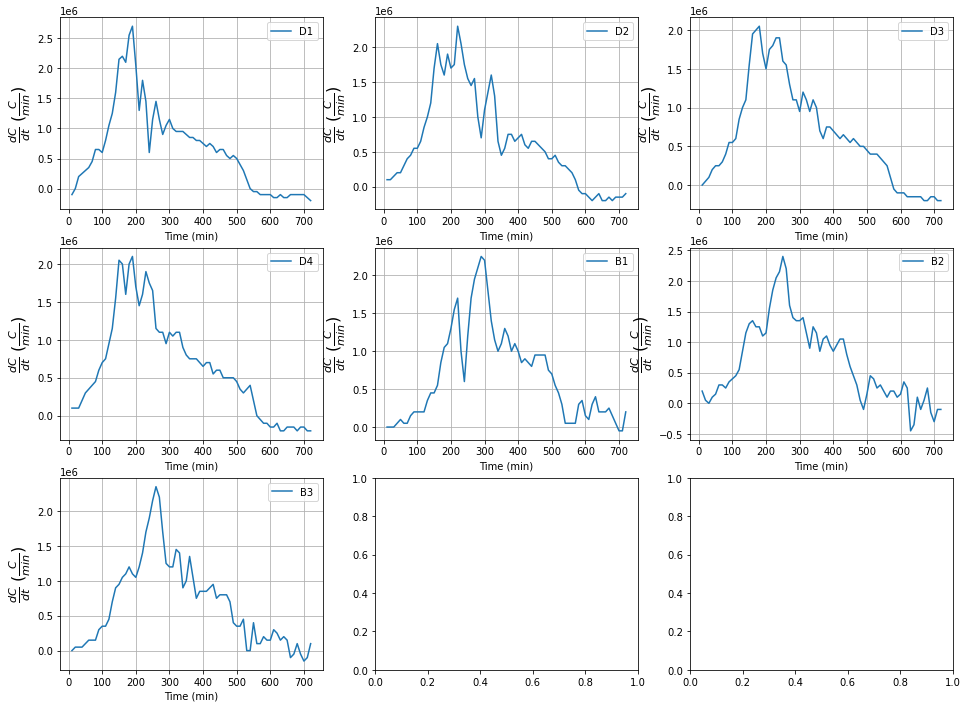

In [4]:
# Convert OD to cell concentration
C_OD = 1e9
C1 = D1 * C_OD
C2 = D2 * C_OD
C3 = D3 * C_OD
C4 = D4 * C_OD
C5 = B1 * C_OD
C6 = B2 * C_OD
C7 = B3 * C_OD

C_av = (C1 + C2 + C3 + C4 + C5 + C6 + C7) / 7
C_max = np.max(C_av)

# First derivative dC/dt
dCdt_1 = np.gradient(C1, time)
dCdt_2 = np.gradient(C2, time)
dCdt_3 = np.gradient(C3, time)
dCdt_4 = np.gradient(C4, time)
dCdt_5 = np.gradient(C5, time)
dCdt_6 = np.gradient(C6, time)
dCdt_7 = np.gradient(C7, time)  # Fixed here

fig, ax = plt.subplots(3, 3, figsize=(16, 12))
for i, (dCdt, label) in enumerate(zip(
    [dCdt_1, dCdt_2, dCdt_3, dCdt_4, dCdt_5, dCdt_6, dCdt_7],
    ['D1', 'D2', 'D3', 'D4', 'B1', 'B2', 'B3']
)):
    r, c = divmod(i, 3)
    ax[r][c].plot(time, dCdt, label=label)
    ax[r][c].set_xlabel('Time (min)')
    ax[r][c].set_ylabel(r'$\frac{dC}{dt} \; (\frac{C}{min})$', fontsize=16)
    ax[r][c].grid(True)
    ax[r][c].legend()

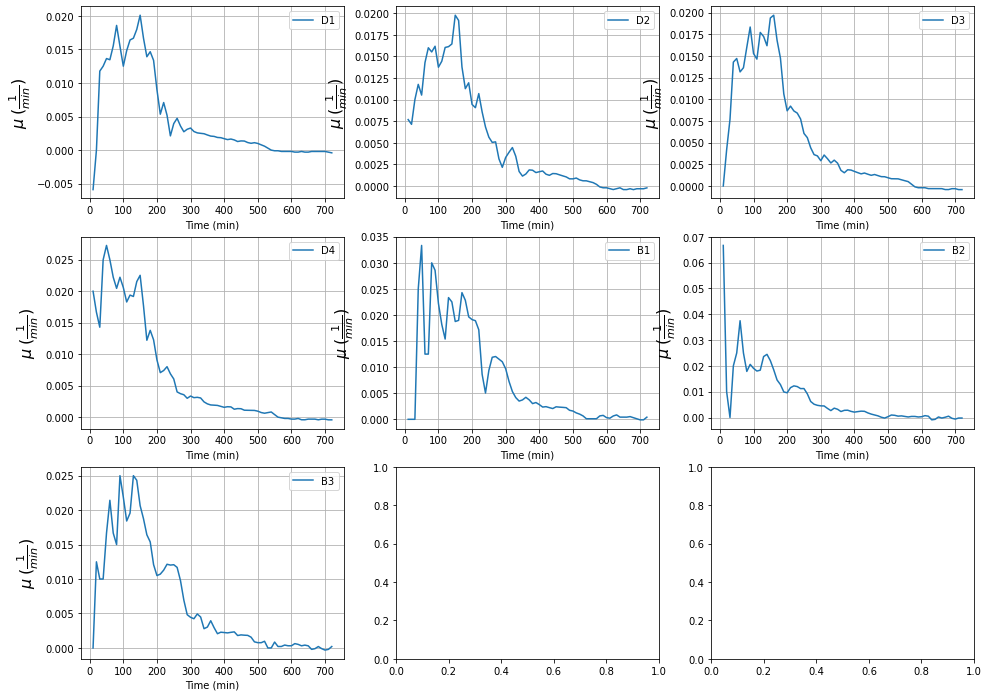

In [5]:
# Specific growth rates mu = (1/C) * dC/dt
def safe_mu(C, time):
    return np.where(C > 1e-8, np.gradient(C, time)/C, 0)

mu_1 = safe_mu(C1, time)
mu_2 = safe_mu(C2, time)
mu_3 = safe_mu(C3, time)
mu_4 = safe_mu(C4, time)
mu_5 = safe_mu(C5, time)
mu_6 = safe_mu(C6, time)
mu_7 = safe_mu(C7, time)

fig, ax = plt.subplots(3, 3, figsize=(16, 12))
for i, (mu, label) in enumerate(zip(
    [mu_1, mu_2, mu_3, mu_4, mu_5, mu_6, mu_7],
    ['D1', 'D2', 'D3', 'D4', 'B1', 'B2', 'B3']
)):
    r, c = divmod(i, 3)
    ax[r][c].plot(time, mu, label=label)
    ax[r][c].set_xlabel('Time (min)')
    ax[r][c].set_ylabel(r'$\mu \; (\frac{1}{min})$', fontsize=16)
    ax[r][c].grid(True)
    ax[r][c].legend()

<ipython-input-6-85c210aafc6a>:2: RuntimeWarning: divide by zero encountered in true_divide
  td_list = [np.where(mu > 0, np.log(2)/mu, np.nan) for mu in [mu_1, mu_2, mu_3, mu_4, mu_5, mu_6, mu_7]]


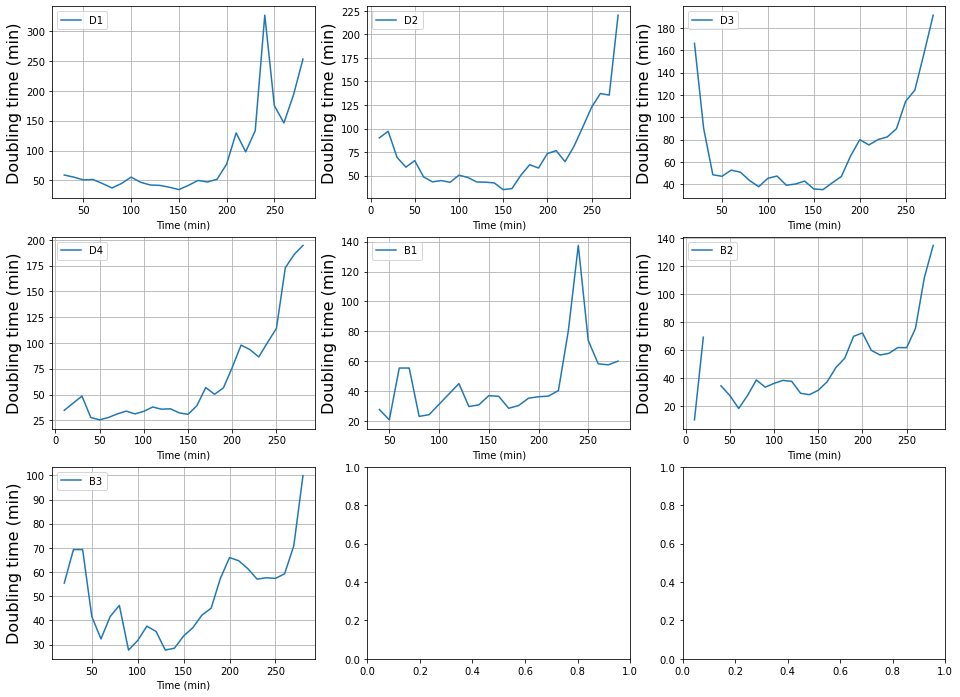

In [6]:
# Doubling time
td_list = [np.where(mu > 0, np.log(2)/mu, np.nan) for mu in [mu_1, mu_2, mu_3, mu_4, mu_5, mu_6, mu_7]]
labels = ['D1', 'D2', 'D3', 'D4', 'B1', 'B2', 'B3']

fig, ax = plt.subplots(3, 3, figsize=(16, 12))
f = 0.4
last_i = int(len(time) * f)

for i, (td, label) in enumerate(zip(td_list, labels)):
    r, c = divmod(i, 3)
    ax[r][c].plot(time[:last_i], td[:last_i], label=label)
    ax[r][c].set_xlabel('Time (min)')
    ax[r][c].set_ylabel('Doubling time (min)', fontsize=16)
    ax[r][c].grid(True)
    ax[r][c].legend()

In [7]:
# Initial and max values
C_list = [C1, C2, C3, C4, C5, C6, C7]
C0_list = [np.min(C) for C in C_list]
Cmax_list = [np.max(C) for C in C_list]

N = int(len(C1)*0.51)
k_gr1 = np.average(dCdt_1[:N]/(C1[:N] * (1 - C1[:N]/Cmax_list[0])))

k_gr1


0.013185452676568005

In [8]:
def log_growth(c, t, k_gr, C_max):
    return k_gr * c * (1 - c / C_max)

def growth_error(p):
    error = 0
    for i, (C, k_gr) in enumerate(zip(C_list, p)):
        C0 = np.min(C)
        Cmax = np.max(C)
        sol = scint.odeint(log_growth, C0, time, args=(k_gr, Cmax), hmax=10, rtol=1e-4).flatten()
        error += np.sum((sol - C)**2)
    return error

In [9]:
# Optimization
p0 = np.array([0.009]*7)
sol = scopt.minimize(growth_error, p0, method='nelder-mead')
k_gr_values = sol.x
k_gr_values

array([0.01481465, 0.01493478, 0.01493515, 0.01885024, 0.01739013,
       0.01886247, 0.01667254])

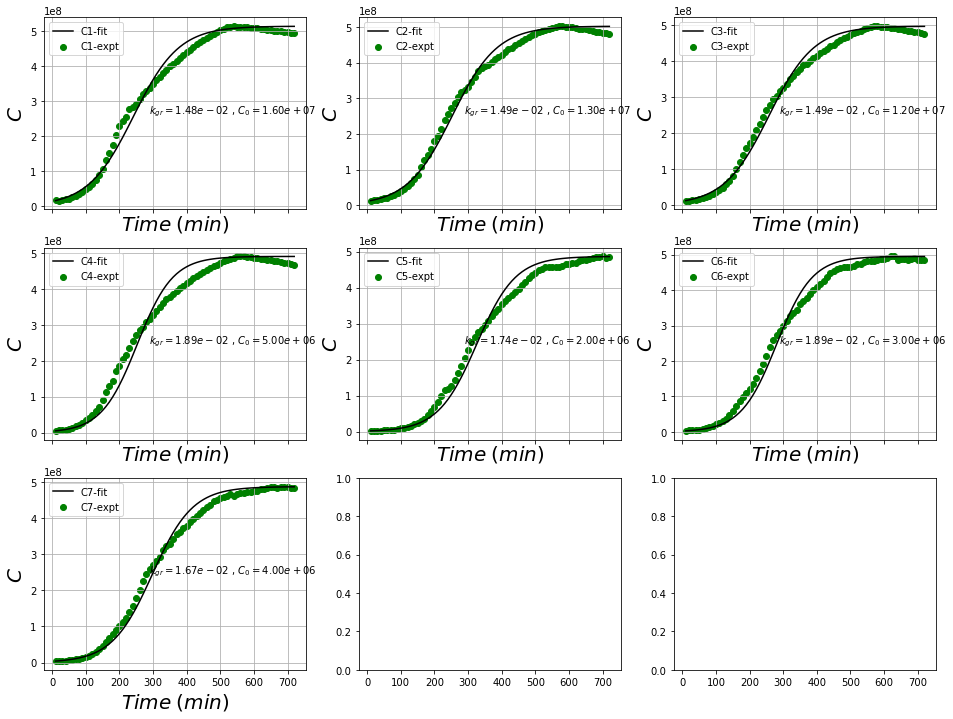

In [10]:
# Plot fits
fig, ax = plt.subplots(3, 3, figsize=(16, 12), sharex='col')
xy = (0.4, 0.5)

for i, (C, k_gr, C0, Cmax) in enumerate(zip(C_list, k_gr_values, C0_list, Cmax_list)):
    r, c = divmod(i, 3)
    sol = scint.odeint(log_growth, C0, time, args=(k_gr, Cmax), hmax=10, rtol=1e-4).flatten()
    ax[r][c].plot(time, sol, label=f'C{i+1}-fit', color='black')
    ax[r][c].scatter(time, C, label=f'C{i+1}-expt', color='green')
    ax[r][c].set_xlabel('$Time \; (min)$', fontsize=20)
    ax[r][c].set_ylabel(r'$C$', fontsize=20)
    text = rf"$k_{{gr}} = {k_gr:.2e}$ , $C_0 = {C0:.2e}$"
    ax[r][c].annotate(text, xy=xy, xytext=xy, textcoords='axes fraction')
    ax[r][c].grid(True)
    ax[r][c].legend()

In [11]:
# # Obtain the growth rates (dC/dt)
# dC2dt2_1 = np.gradient(dCdt_1)
# dC2dt2_2 = np.gradient(dCdt_2)
# dC2dt2_3 = np.gradient(dCdt_3)
# dC2dt2_4 = np.gradient(dCdt_4)
# dC2dt2_5 = np.gradient(dCdt_5)
# dC2dt2_6 = np.gradient(dCdt_6)

# fig, ax = plt.subplots(2,3, figsize = (16,8))
# ax[0][0].plot(time, dC2dt2_1, label = 'A1')
# ax[0][0].set_xlabel('Time (min)'); ax[0][0].set_ylabel(r'$\frac{dC}{dt} \; (\frac{C}{min})$', fontsize = 16)
# ax[0][0].grid(True); ax[0][0].legend()

# ax[0][1].plot(time,dC2dt2_2, label = 'A2')
# ax[0][1].set_xlabel('Time (min)'); #ax[0].set_ylabel(r'$\frac{dC}{dt}$', rotation = 0, fontsize = 16)
# ax[0][1].grid(True); ax[0][1].legend()

# ax[0][2].plot(time, dC2dt2_3, label = 'A3')
# ax[0][2].set_xlabel('Time (min)'); #ax[0].set_ylabel(r'$\frac{dC}{dt}$', rotation = 0, fontsize = 16)
# ax[0][2].grid(True); ax[0][2].legend()

# ax[1][0].plot(time, dC2dt2_4, label = 'B1')
# ax[1][0].set_xlabel('Time (min)'); ax[1][0].set_ylabel(r'$\frac{dC}{dt} \; (\frac{C}{min})$', fontsize = 16)
# ax[1][0].grid(True); ax[1][0].legend()

# ax[1][1].plot(time, dC2dt2_5, label = 'B2')
# ax[1][1].set_xlabel('Time (min)'); #ax[0].set_ylabel(r'$\frac{dC}{dt}$', rotation = 0, fontsize = 16)
# ax[1][1].grid(True); ax[1][1].legend()

# ax[1][2].plot(time, dC2dt2_6, label = 'B3')
# ax[1][2].set_xlabel('Time (min)'); #ax[0].set_ylabel(r'$\frac{dC}{dt}$', rotation = 0, fontsize = 16)
# ax[1][2].grid(True); ax[1][2].legend()